# SHERLOC Spectral Analysis API Example

This notebook demonstrates the Python API for SHERLOC spectral analysis workflows.

The API provides clean, functional interfaces for:
- Processing averaged spectra from Loupe data
- Loading pre-processed point spectra from pipeline outputs
- Loading reference mineral spectra for comparison
- Creating publication-quality overlay plots

**Note:** This notebook uses test fixtures. In production, point your paths to actual data directories.


In [ ]:
# Setup and imports
from pathlib import Path
import matplotlib.pyplot as plt

# Import the SHERLOC API functions
from sherloc_pipeline.api.spectral import (
    process_scan_average,
    process_subset_average,
    process_point,
    load_point_spectrum,
    load_reference_spectrum,
    plot_spectrum,
    plot_overlay,
)

# Define paths to test fixtures
# In production, use your actual data directories:
#   data_dir = Path("/path/to/data/loupe")
#   results_dir = Path("/path/to/results")
DATA_DIR = Path("../tests/fixtures/loupe")
RESULTS_DIR = Path("../tests/fixtures/pipeline_outputs")
REFERENCE_DIR = Path("../../data/reference")  # Reference spectra in data/reference

print("API imported successfully!")


API imported successfully!


## 1. Processing Averaged Spectra

The `process_scan_average()` function loads raw Loupe data and produces a fully-processed 
averaged spectrum with optional:
- Background subtraction (Arm Stowed or Fused Silica)
- Baseline correction (asPLS algorithm)
- Gaussian peak fitting

Returns a tuple of (DataFrame, Optional[FitResult]).


In [2]:
# Process an averaged spectrum with background subtraction and baseline correction
df_averaged, _ = process_scan_average(
    sol="0921",
    target="Amherst_Point",
    scan="detail_1",
    avg_method="trim-mean",  # Robust averaging
    trim_pct=2.0,            # 2% trimmed mean
    background="fs",         # Fused silica background
    bgscale="auto",          # PPP-based automatic scaling
    baseline=True,           # Apply baseline correction
    fit=False,               # No fitting for now
    data_dir=DATA_DIR,
)

print(f"DataFrame shape: {df_averaged.shape}")
print(f"Columns: {df_averaged.columns.tolist()}")
print(f"Raman shift range: {df_averaged['raman_shift'].min():.1f} - {df_averaged['raman_shift'].max():.1f} cm⁻¹")
df_averaged.head()


DataFrame shape: (523, 2)
Columns: ['raman_shift', 'intensity']
Raman shift range: 238.4 - 4765.1 cm⁻¹


,raman_shift,intensity
0,238.393143,15.845042
1,248.691962,6.520879
2,258.982969,-8.300084
3,269.266172,1.482786
4,279.541580,0.157966


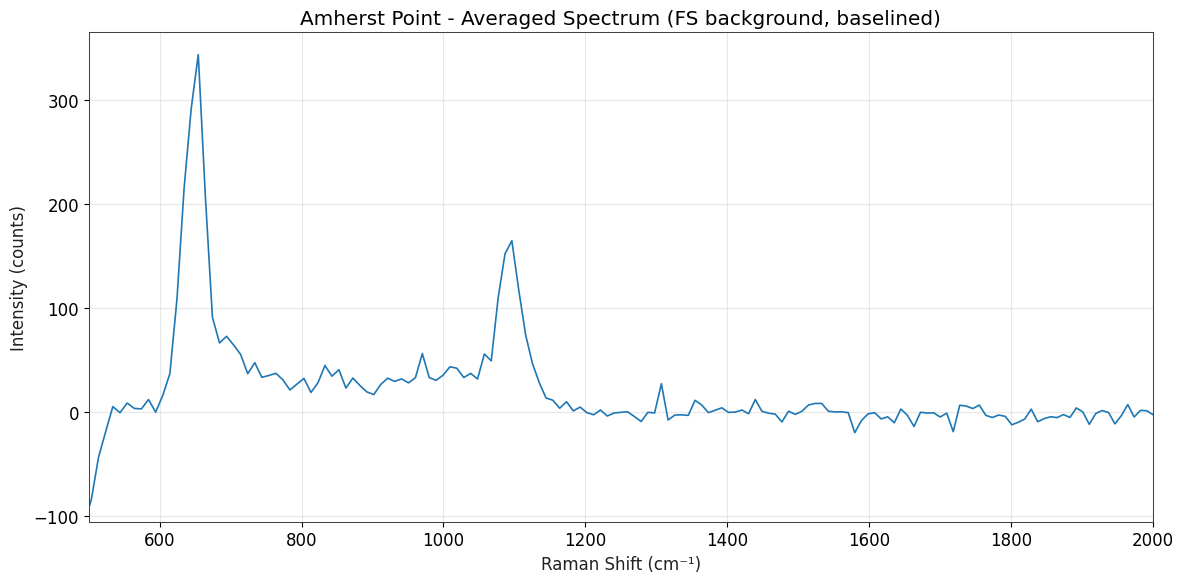

In [3]:
# Visualize the processed spectrum
fig = plot_spectrum(
    df_averaged,
    xlim=(500, 2000),
    title="Amherst Point - Averaged Spectrum (FS background, baselined)",
)
plt.show()


### With Gaussian Fitting

Enable `fit=True` to perform automatic multi-Gaussian peak fitting in the mineral region.


In [4]:
# Process with Gaussian fitting
df_fitted, fit_result = process_scan_average(
    sol="0921",
    target="Amherst_Point",
    scan="detail_1",
    background="fs",
    baseline=True,
    fit=True,
    fit_range=(700, 1200),  # Focus on R1 mineral region
    data_dir=DATA_DIR,
)

# Show fit results
if fit_result:
    print(f"Number of peaks: {len(fit_result.peaks)}")
    print(f"Overall R²: {fit_result.r2:.3f}")
    print("\nPeak parameters:")
    for i, peak in enumerate(fit_result.peaks):
        print(f"  Peak {i+1}: center={peak.m_cm1:.1f} cm⁻¹, FWHM={peak.fwhm:.1f} cm⁻¹, SNR={peak.snr:.1f}")


Number of peaks: 5
Overall R²: 0.942

Peak parameters:
  Peak 1: center=711.8 cm⁻¹, FWHM=90.0 cm⁻¹, SNR=9.8
  Peak 2: center=837.9 cm⁻¹, FWHM=90.0 cm⁻¹, SNR=6.6
  Peak 3: center=959.6 cm⁻¹, FWHM=90.0 cm⁻¹, SNR=6.7
  Peak 4: center=1028.5 cm⁻¹, FWHM=56.2 cm⁻¹, SNR=5.7
  Peak 5: center=1094.1 cm⁻¹, FWHM=44.7 cm⁻¹, SNR=28.2


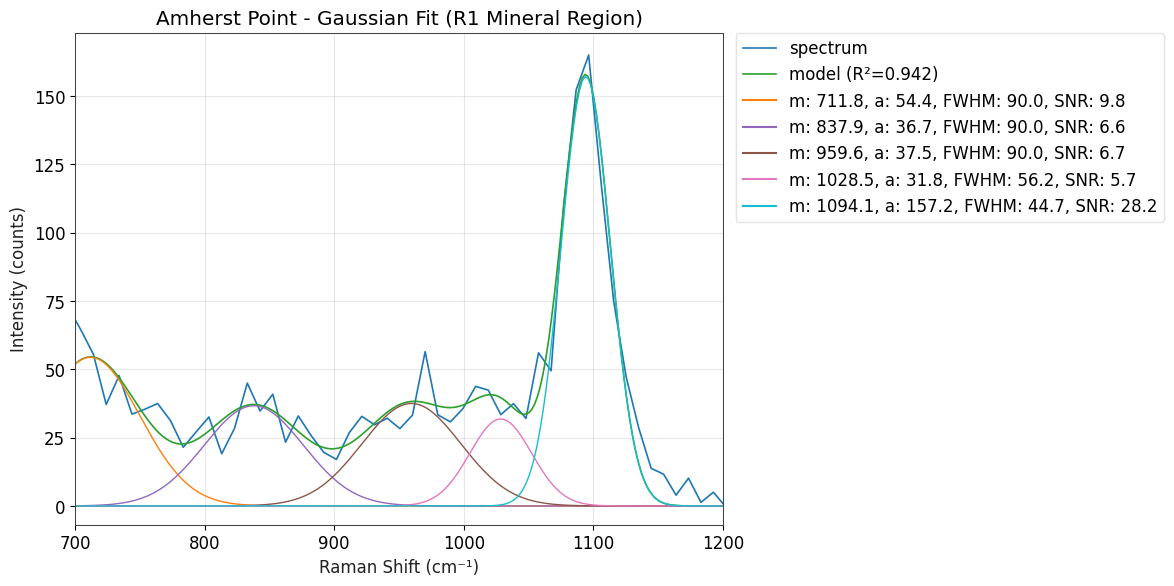

In [5]:
# Plot with fit overlay
fig = plot_spectrum(
    df_fitted,
    fit_result=fit_result,
    xlim=(700, 1200),
    title="Amherst Point - Gaussian Fit (R1 Mineral Region)",
)
plt.show()


## 2. Loading Point Spectra from Pipeline Outputs

The `load_point_spectrum()` function loads pre-processed spectra from the pipeline's 
results directory. This is useful for examining individual point spectra after 
running the full pipeline.


In [6]:
# Load a specific point spectrum from pipeline outputs
df_point = load_point_spectrum(
    sol="0921",
    target="Amherst_Point",
    scan="detail_1",
    point=5,
    level="normalized_baselined",  # Options: normalized, normalized_baselined, normalized_despiked_baselined
    results_dir=RESULTS_DIR,
)

print(f"Loaded point 5, level: normalized_baselined")
print(f"DataFrame shape: {df_point.shape}")
df_point.head()


Loaded point 5, level: normalized_baselined
DataFrame shape: (32, 2)


,raman_shift,intensity
0,238.393,75.729917
1,248.692,120.989307
2,258.983,115.175350
3,269.266,110.936811
4,279.542,78.071694


### Processing Single Points from Loupe Data

While `load_point_spectrum()` loads pre-processed spectra from pipeline outputs (existing results),
`process_point()` processes a single point directly from raw Loupe data with the full processing chain:
background subtraction, baseline correction, and Gaussian fitting.

This is useful when you want to analyze specific points without running the full pipeline,
or when comparing individual points with averaged spectra.


In [ ]:
# Process single point from Loupe data with fitting
df_single_point, fit_point = process_point(
    sol="0921",
    target="Amherst_Point",
    scan="detail_1",
    point=5,                 # Process point index 5
    background="fs",         # Apply fused silica background subtraction
    baseline=True,           # Apply baseline correction
    fit=True,                # Perform Gaussian fitting
    fit_range=(700, 1200),   # Focus on R1 mineral region
    data_dir=DATA_DIR,
)

print(f"Processed point 5 from Loupe data")
print(f"DataFrame shape: {df_single_point.shape}")

if fit_point:
    print(f"\nFit results:")
    print(f"  Number of peaks: {len(fit_point.peaks)}")
    print(f"  R²: {fit_point.r2:.3f}")
    for i, peak in enumerate(fit_point.peaks):
        print(f"  Peak {i+1}: {peak.m_cm1:.1f} cm⁻¹ (SNR={peak.snr:.1f})")


In [ ]:
# Compare single point spectrum with averaged spectrum
# Use the averaged spectrum we processed earlier (df_averaged)

fig = plot_overlay(
    spectra=[
        {
            "df": df_single_point,
            "label": "Point 5 (single point)",
            "color": "#d62728",  # Red
            "linewidth": 1.0,
        },
        {
            "df": df_averaged,
            "label": "All points (averaged)",
            "color": "#1f77b4",  # Blue
            "linewidth": 1.5,
        },
    ],
    xlim=(700, 1400),
    title="Single Point vs Averaged Spectrum - Amherst Point",
)
plt.show()


## 3. Loading Reference Spectra

The `load_reference_spectrum()` function loads lab-measured mineral reference spectra
for comparison with Mars data. This is essential for mineral identification.


In [7]:
# Load a reference mineral spectrum (Magnesite - carbonate)
ref_magnesite = load_reference_spectrum(
    mineral="magnesite",  # Case-insensitive, partial matching supported
    library_path=REFERENCE_DIR,
)

print(f"Magnesite (carbonate) reference loaded")
print(f"DataFrame shape: {ref_magnesite.shape}")
print(f"Raman shift range: {ref_magnesite['raman_shift'].min():.1f} - {ref_magnesite['raman_shift'].max():.1f} cm⁻¹")

# Show the carbonate peak region
carbonate_mask = (ref_magnesite['raman_shift'] >= 1050) & (ref_magnesite['raman_shift'] <= 1150)
print(f"\nCarbonate peak region (1050-1150 cm⁻¹):")
print(ref_magnesite[carbonate_mask])


Magnesite (carbonate) reference loaded
DataFrame shape: (2048, 2)
Raman shift range: -283.4 - 12225.9 cm⁻¹

Carbonate peak region (1050-1150 cm⁻¹):
     raman_shift     intensity
128  1053.791683    768.365028
129  1063.767796   2245.187182
130  1073.736920   5331.021477
131  1083.699059   8528.322286
132  1093.654222  10212.634886
133  1103.602416  10054.504555
134  1113.543646   8059.249295
135  1123.477919   5301.050745
136  1133.405243   2894.817816
137  1143.325624   1234.868506


## 4. Multi-Spectrum Overlay Plots

The `plot_overlay()` function creates publication-quality overlay plots comparing 
multiple spectra. This is particularly useful for:
- Comparing Mars spectra with reference minerals
- Comparing different scan targets
- Visualizing spectral evolution across locations


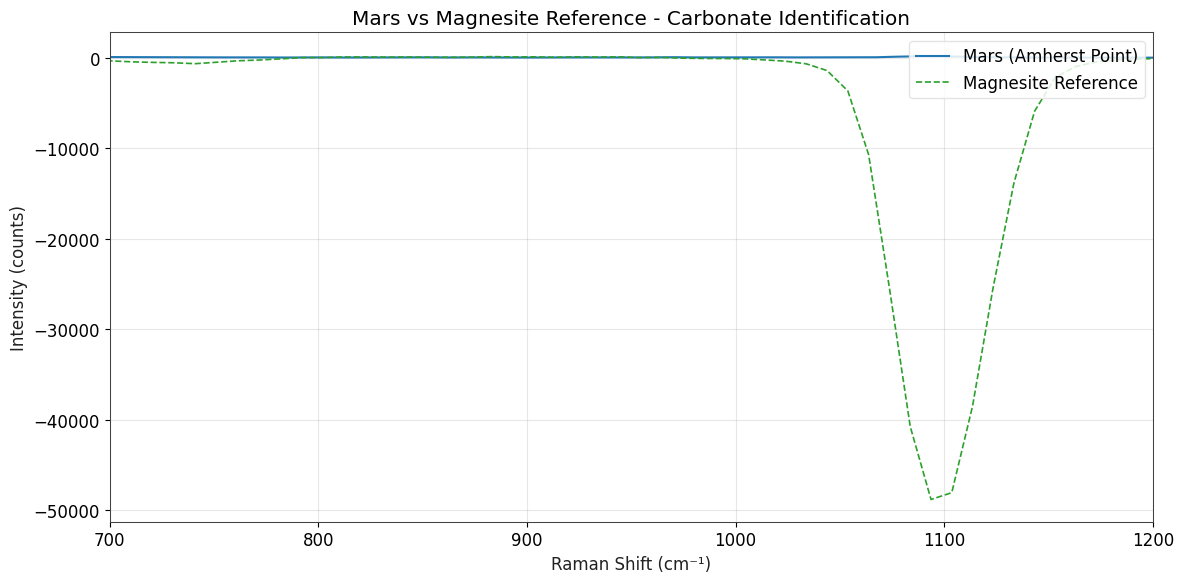

In [ ]:
# Compare Mars spectrum with Magnesite (carbonate) reference
# Using scale_to_peak to normalize both spectra to the carbonate peak region (~1090 cm⁻¹)

fig = plot_overlay(
    spectra=[
        {
            "df": df_averaged,
            "label": "Mars (Amherst Point sol 921)",
            "color": "#1f77b4",
            "linewidth": 1.5,
        },
        {
            "df": ref_magnesite,
            "label": "Magnesite (Carbonate) Reference",
            "color": "#d62728",
            "linestyle": "--",
            "linewidth": 1.2,
        },
    ],
    xlim=(1000, 1200),  # Focus on carbonate region
    scale_to_peak=(1080, 1110),  # Normalize to carbonate peak at ~1090 cm⁻¹
    title="Mars vs Magnesite Reference - Carbonate Identification",
    legend_loc="upper right",
)
plt.show()


In [ ]:
# Compare two different Mars targets

# Load second target
df_lake_haiyaha, _ = process_scan_average(
    sol="0852",
    target="Lake_Haiyaha",
    scan="detail_1",
    background="fs",
    baseline=True,
    data_dir=DATA_DIR,
)

# Create overlay comparing both Mars targets
fig = plot_overlay(
    spectra=[
        {
            "df": df_averaged,
            "label": "Amherst Point (sol 921)",
            "color": "#1f77b4",
        },
        {
            "df": df_lake_haiyaha,
            "label": "Lake Haiyaha (sol 852)",
            "color": "#ff7f0e",
        },
    ],
    xlim=(700, 1200),
    title="Mars Target Comparison - Mineral Region",
)
plt.show()


## Summary

This notebook demonstrated the core SHERLOC spectral analysis API functions:

| Function | Purpose |
|----------|---------|
| `process_scan_average()` | Process raw Loupe data into averaged spectrum with bg-sub, baseline, fitting |
| `process_subset_average()` | Average specific point indices (like label-based averaging) |
| `process_point()` | Process single point from raw Loupe data with full processing chain |
| `load_point_spectrum()` | Load pre-processed point spectra from pipeline results |
| `load_reference_spectrum()` | Load reference mineral spectra for comparison |
| `plot_spectrum()` | Create single spectrum plots with optional fit overlay |
| `plot_overlay()` | Create multi-spectrum comparison plots |

For more details, see the API docstrings or the PRD documentation.
